# PrePol Model Training Pipeline
## RandomForest Regression for Crime Hotspot Forecasting

This notebook trains a RandomForest regression model using the preprocessed panel data from `PrePol_panel_export.parquet`.

## 1. Import Libraries and Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# Add prepol module to path
sys.path.append(str(Path.cwd().parent))
from prepol.config import OUTPUT_DIR, RANDOM_STATE, MODEL_PREFIX

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Panel Data

In [2]:
# Load the panel data
panel_file = Path("prepol_out/PrePol_Panel_25_11_2025_by_crimetype_weekly.parquet")
df_panel = pd.read_parquet(panel_file)

print(f"✓ Loaded panel data: {df_panel.shape}")
print(f"\nColumns: {list(df_panel.columns)}")
print(f"\nDate range: {df_panel['time_period'].min()} to {df_panel['time_period'].max()}")
print(f"\nTarget variable (y) stats:")
print(df_panel['y'].describe())

# Display sample
df_panel.head()

✓ Loaded panel data: (40487945, 12)

Columns: ['h3_cell', 'time_period', 'RUBRICA', 'crime_type_encoded', 'y', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']

Date range: 2297 to 2453

Target variable (y) stats:
count    4.048794e+07
mean     2.291000e-02
std      1.784501e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.500000e+01
Name: y, dtype: float64
count    4.048794e+07
mean     2.291000e-02
std      1.784501e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.500000e+01
Name: y, dtype: float64


,h3_cell,time_period,RUBRICA,crime_type_encoded,y,y_norm,y_lag_1,y_lag_2,y_lag_3,y_rol_3,y_rol_7,y_lag_1_vizinhos
0,8aa810000007fff,2297,Furto (art. 155),0,0,-0.113230,NaN,NaN,NaN,NaN,NaN,NaN
1,8aa810000007fff,2298,Furto (art. 155),0,0,-0.113230,0.0,NaN,NaN,0.0,0.0,NaN
2,8aa810000007fff,2299,Furto (art. 155),0,0,-0.113230,0.0,0.0,NaN,0.0,0.0,NaN
3,8aa810000007fff,2300,Furto (art. 155),0,0,-0.113230,0.0,0.0,0.0,0.0,0.0,NaN
4,8aa810000007fff,2301,Furto (art. 155),0,1,8.775327,0.0,0.0,0.0,0.0,0.0,NaN


In [3]:
# Final Panel Summary
print("FINAL PANEL SUMMARY")
print("=" * 70)
print(f"Shape: {df_panel.shape}")
print(f"Date range: {df_panel['time_period'].min()} to {df_panel['time_period'].max()}")
print(f"Unique cells: {df_panel['h3_cell'].nunique():,}")
print(f"Unique periods: {df_panel['time_period'].nunique():,}")
print(f"Target (y) - Mean: {df_panel['y'].mean():.4f}, Std: {df_panel['y'].std():.4f}")
print(f"Zero crime periods: {(df_panel['y'] == 0).sum():,} ({(df_panel['y'] == 0).sum()/len(df_panel)*100:.1f}%)")
print("=" * 70)

df_panel.head(10)

FINAL PANEL SUMMARY
Shape: (40487945, 12)
Date range: 2297 to 2453
Unique cells: 51,577
Unique cells: 51,577
Unique periods: 157
Unique periods: 157
Target (y) - Mean: 0.0229, Std: 0.1785
Zero crime periods: 39,667,957 (98.0%)
Target (y) - Mean: 0.0229, Std: 0.1785
Zero crime periods: 39,667,957 (98.0%)


,h3_cell,time_period,RUBRICA,crime_type_encoded,y,y_norm,y_lag_1,y_lag_2,y_lag_3,y_rol_3,y_rol_7,y_lag_1_vizinhos
0,8aa810000007fff,2297,Furto (art. 155),0,0,-0.113230,NaN,NaN,NaN,NaN,NaN,NaN
1,8aa810000007fff,2298,Furto (art. 155),0,0,-0.113230,0.0,NaN,NaN,0.000000,0.000000,NaN
2,8aa810000007fff,2299,Furto (art. 155),0,0,-0.113230,0.0,0.0,NaN,0.000000,0.000000,NaN
3,8aa810000007fff,2300,Furto (art. 155),0,0,-0.113230,0.0,0.0,0.0,0.000000,0.000000,NaN
4,8aa810000007fff,2301,Furto (art. 155),0,1,8.775327,0.0,0.0,0.0,0.000000,0.000000,NaN
5,8aa810000007fff,2302,Furto (art. 155),0,0,-0.113230,1.0,0.0,0.0,0.333333,0.200000,NaN
6,8aa810000007fff,2303,Furto (art. 155),0,0,-0.113230,0.0,1.0,0.0,0.333333,0.166667,NaN
7,8aa810000007fff,2304,Furto (art. 155),0,0,-0.113230,0.0,0.0,1.0,0.333333,0.142857,NaN
8,8aa810000007fff,2305,Furto (art. 155),0,0,-0.113230,0.0,0.0,0.0,0.000000,0.142857,NaN
9,8aa810000007fff,2306,Furto (art. 155),0,0,-0.113230,0.0,0.0,0.0,0.000000,0.142857,NaN


## 3. Data Preparation and Feature Engineering

In [4]:
# Prepare features and target
df_model = df_panel.copy()

# Convert Period columns to ordinal integers (if any)
for col in df_model.columns:
    if pd.api.types.is_period_dtype(df_model[col]):
        print(f"Converting Period column '{col}' to ordinal...")
        df_model[col] = df_model[col].apply(lambda x: x.ordinal if pd.notna(x) else np.nan)

# Identify feature columns (exclude target and metadata)
exclude_cols = ['y', 'time_period', 'h3_cell']
feature_cols = [col for col in df_model.columns if col not in exclude_cols]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Separate features and target
X = df_model[feature_cols].copy()
y = df_model['y']

# Handle missing values
print(f"\nMissing values before handling:")
missing = X.isnull().sum()[X.isnull().sum() > 0]
if len(missing) > 0:
    print(missing)
else:
    print("  No missing values")

# Fill NaN with 0 for numeric columns only (categorical columns can't be filled with values not in categories)
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(0)
    elif pd.api.types.is_categorical_dtype(X[col]):
        # For categorical columns, convert to numeric codes (handles NaN as -1)
        X[col] = X[col].cat.codes

print(f"\n✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Missing values after handling: {X.isnull().sum().sum()}")


Feature columns (9): ['RUBRICA', 'crime_type_encoded', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']

Missing values before handling:

Missing values before handling:
y_lag_1               257885
y_lag_2               515770
y_lag_3               773655
y_rol_3               257885
y_rol_7               257885
y_lag_1_vizinhos    40487945
dtype: int64
y_lag_1               257885
y_lag_2               515770
y_lag_3               773655
y_rol_3               257885
y_rol_7               257885
y_lag_1_vizinhos    40487945
dtype: int64

✓ Features shape: (40487945, 9)
✓ Target shape: (40487945,)

✓ Features shape: (40487945, 9)
✓ Target shape: (40487945,)
✓ Missing values after handling: 0
✓ Missing values after handling: 0


## 4. Train-Test Split (Temporal)

In [5]:
# Check data types in features
print("Data types in the panel:")
print(df_panel.dtypes)
print("\n" + "="*60)

Data types in the panel:
h3_cell               category
time_period              int64
RUBRICA               category
crime_type_encoded       int64
y                         int8
y_norm                 float32
y_lag_1                float64
y_lag_2                float64
y_lag_3                float64
y_rol_3                float64
y_rol_7                float64
y_lag_1_vizinhos       float64
dtype: object



In [6]:
# Use temporal split to respect time series nature
# Sort by time_period to ensure temporal ordering
df_model = df_model.sort_values('time_period').reset_index(drop=True)

# Recreate X with proper handling (since we sorted df_model)
X = df_model[feature_cols].copy()
y = df_model['y']

# Handle missing values with proper dtype handling
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(0)
    elif pd.api.types.is_categorical_dtype(X[col]):
        X[col] = X[col].cat.codes

# Use 80-20 split maintaining temporal order
split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

train_dates = df_model['time_period'].iloc[:split_idx]
test_dates = df_model['time_period'].iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"  Date range: {train_dates.min()} to {train_dates.max()}")
print(f"  Target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  Date range: {test_dates.min()} to {test_dates.max()}")
print(f"  Target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")


Training set: 32390356 samples
  Date range: 2297 to 2422
  Target mean: 0.02, std: 0.17

Test set: 8097589 samples
  Date range: 2422 to 2453
  Target mean: 0.03, std: 0.22
  Target mean: 0.02, std: 0.17

Test set: 8097589 samples
  Date range: 2422 to 2453
  Target mean: 0.03, std: 0.22


## 5. Train RandomForest Regression Model

In [7]:
# Initialize RandomForest Regressor
print("Training RandomForest Regression model...")
print("-" * 60)

# Track training progress
import time
start_time = time.time()

# Memory usage before training
import psutil
process = psutil.Process()
mem_before = process.memory_info().rss / 1024 / 1024 / 1024  # GB

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2  # Changed from 1 to 2 for more detailed progress
)

print(f"Training data shape: {X_train.shape}")
print(f"Memory usage before training: {mem_before:.2f} GB")
print(f"Starting training at {datetime.now().strftime('%H:%M:%S')}...")
print()

# Train the model (verbose=2 shows progress per tree)
rf_model.fit(X_train, y_train)

# Calculate training time
elapsed_time = time.time() - start_time
mem_after = process.memory_info().rss / 1024 / 1024 / 1024  # GB
mem_increase = mem_after - mem_before

print()
print("=" * 60)
print("✓ Model training complete!")
print("=" * 60)
print(f"Training time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print(f"Memory usage after training: {mem_after:.2f} GB")
print(f"Memory increase during training: {mem_increase:.2f} GB")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")
print(f"Completed at {datetime.now().strftime('%H:%M:%S')}")
print("=" * 60)


Training RandomForest Regression model...
------------------------------------------------------------
Training data shape: (32390356, 9)
Memory usage before training: 5.11 GB
Starting training at 14:30:16...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 13 of 100
building tree 14 of 100
building tree 14 of 100
building tree 15 of 100
building tree 15 of 100
building tree 16 of 100
building tree 16 of 100
building tree 17 of 100
building tree 17 of 100
building tree 18 of 100
building tree 18 of 100
building tree 19 of 100
building tree 19 of 100
building tree 20 of 100
building tree 20 of 100
building tree 21 of 100
building tree 21 of 100
building tree 22 of 100
building tree 22 of 100
building tree 23 of 100
building tree 23 of 100
building tree 24 of 100
building tree 24 of 100
building tree 25 of 100
building tree 25 of 100
building tree 26 of 100
building tree 26 of 100
building tree 27 of 100
building tree 27 of 100
b

[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  4.0min


building tree 30 of 100
building tree 31 of 100
building tree 31 of 100
building tree 32 of 100
building tree 32 of 100
building tree 33 of 100
building tree 33 of 100
building tree 34 of 100
building tree 34 of 100
building tree 35 of 100
building tree 35 of 100
building tree 36 of 100
building tree 36 of 100
building tree 37 of 100
building tree 37 of 100
building tree 38 of 100
building tree 38 of 100
building tree 39 of 100
building tree 39 of 100
building tree 40 of 100
building tree 40 of 100
building tree 41 of 100
building tree 41 of 100
building tree 42 of 100
building tree 42 of 100
building tree 43 of 100
building tree 43 of 100
building tree 44 of 100
building tree 44 of 100
building tree 45 of 100
building tree 45 of 100
building tree 46 of 100
building tree 46 of 100
building tree 47 of 100
building tree 47 of 100
building tree 48 of 100
building tree 48 of 100
building tree 49 of 100
building tree 49 of 100
building tree 50 of 100
building tree 50 of 100
building tree 51

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 16.0min finished


## 6. Model Evaluation

In [8]:
# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and display regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE with handling for zero values
    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  MAE (Mean Absolute Error):  {mae:.4f}")
    print(f"  MSE (Mean Squared Error):   {mse:.4f}")
    print(f"  RMSE (Root MSE):            {rmse:.4f}")
    print(f"  R² Score:                   {r2:.4f}")
    print(f"  MAPE:                       {mape:.2f}%")
    
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2, 'mape': mape}

print("=" * 60)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 60)

train_metrics = calculate_metrics(y_train, y_train_pred, "TRAINING SET")
test_metrics = calculate_metrics(y_test, y_test_pred, "TEST SET")

print("\n" + "=" * 60)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    4.6s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    4.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:   20.4s finished
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:   20.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    4.8s finished
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    4.8s finished


MODEL PERFORMANCE EVALUATION

TRAINING SET Metrics:
  MAE (Mean Absolute Error):  0.0020
  MSE (Mean Squared Error):   0.0016
  RMSE (Root MSE):            0.0396
  R² Score:                   0.9441
  MAPE:                       6.73%

TRAINING SET Metrics:
  MAE (Mean Absolute Error):  0.0020
  MSE (Mean Squared Error):   0.0016
  RMSE (Root MSE):            0.0396
  R² Score:                   0.9441
  MAPE:                       6.73%

TEST SET Metrics:
  MAE (Mean Absolute Error):  0.0039
  MSE (Mean Squared Error):   0.0032
  RMSE (Root MSE):            0.0563
  R² Score:                   0.9324
  MAPE:                       9.72%


TEST SET Metrics:
  MAE (Mean Absolute Error):  0.0039
  MSE (Mean Squared Error):   0.0032
  RMSE (Root MSE):            0.0563
  R² Score:                   0.9324
  MAPE:                       9.72%



## 7. Feature Importance Analysis

Top 10 Most Important Features:
           feature  importance
            y_norm    0.876957
           y_rol_7    0.061584
           y_rol_3    0.029154
           y_lag_1    0.015739
           y_lag_2    0.008584
           y_lag_3    0.004260
crime_type_encoded    0.001958
           RUBRICA    0.001764
  y_lag_1_vizinhos    0.000000


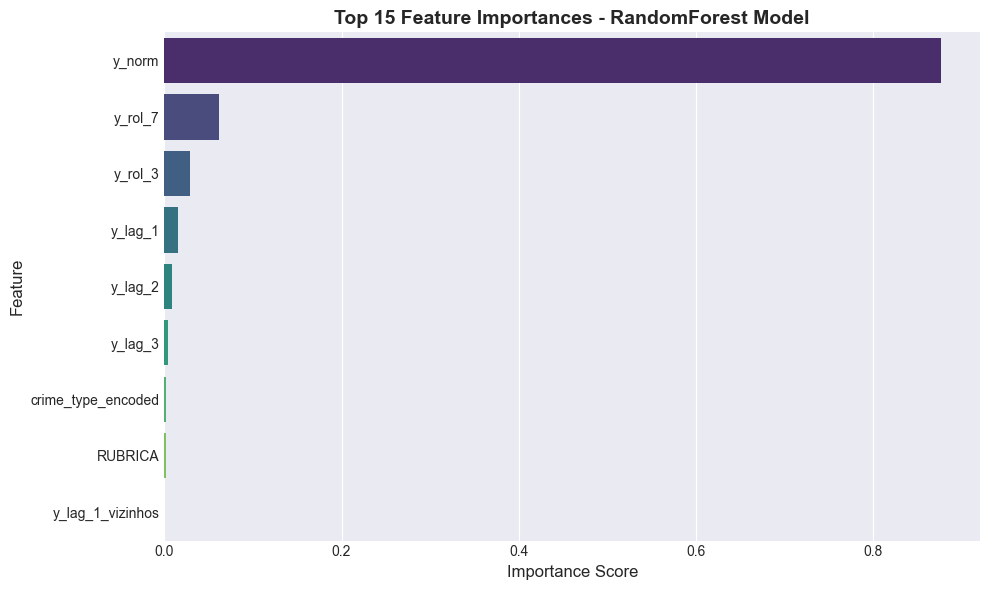

,feature,importance
2,y_norm,0.876957
7,y_rol_7,0.061584
6,y_rol_3,0.029154
3,y_lag_1,0.015739
4,y_lag_2,0.008584
5,y_lag_3,0.004260
1,crime_type_encoded,0.001958
0,RUBRICA,0.001764
8,y_lag_1_vizinhos,0.000000


In [9]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_n = 15
sns.barplot(
    data=feature_importance.head(top_n),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title(f'Top {top_n} Feature Importances - RandomForest Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

feature_importance.head(20)

## 8. Prediction Visualization

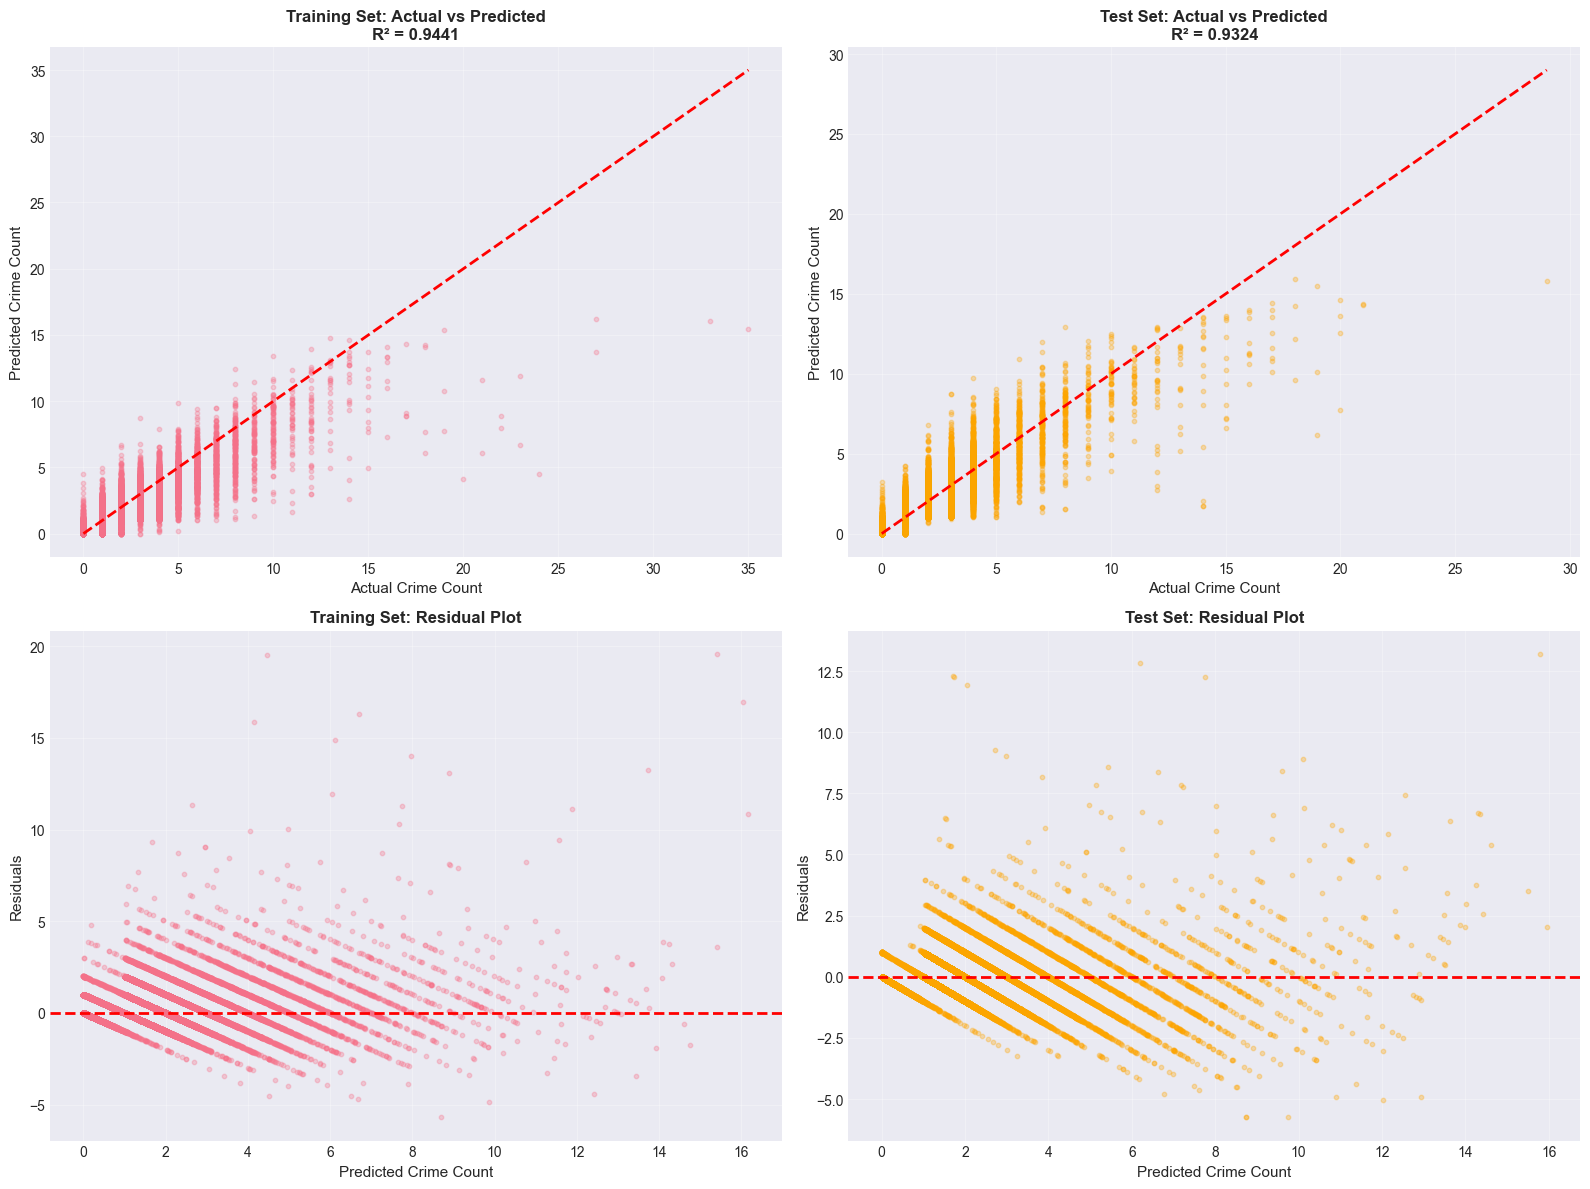

In [10]:
# Create prediction comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted - Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Crime Count', fontsize=11)
axes[0, 0].set_ylabel('Predicted Crime Count', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["r2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted - Test
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Crime Count', fontsize=11)
axes[0, 1].set_ylabel('Predicted Crime Count', fontsize=11)
axes[0, 1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["r2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals - Training
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Crime Count', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Training Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals - Test
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.3, s=10, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Crime Count', fontsize=11)
axes[1, 1].set_ylabel('Residuals', fontsize=11)
axes[1, 1].set_title('Test Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Model and Metadata

In [11]:
# Generate timestamp for model versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Define output paths (parent directory)
model_dir = Path.cwd().parent / "model"
model_dir.mkdir(exist_ok=True)

model_filename = f"{MODEL_PREFIX}_{timestamp}.joblib"
meta_filename = f"{MODEL_PREFIX}_meta_{timestamp}.json"

model_path = model_dir / model_filename
meta_path = model_dir / meta_filename

# Save the model
joblib.dump(rf_model, model_path)
print(f"✓ Model saved: {model_path}")

# Prepare metadata
metadata = {
    "model_type": "RandomForestRegressor",
    "timestamp": timestamp,
    "training_date": datetime.now().isoformat(),
    "model_params": rf_model.get_params(),
    "feature_columns": feature_cols,
    "n_features": len(feature_cols),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
    "train_date_range": {
        "start": str(train_dates.min()),
        "end": str(train_dates.max())
    },
    "test_date_range": {
        "start": str(test_dates.min()),
        "end": str(test_dates.max())
    },
    "metrics": {
        "train": {k: float(v) if not pd.isna(v) else None for k, v in train_metrics.items()},
        "test": {k: float(v) if not pd.isna(v) else None for k, v in test_metrics.items()}
    },
    "top_features": feature_importance.head(10)[['feature', 'importance']].to_dict('records')
}

# Save metadata
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
    
print(f"✓ Metadata saved: {meta_path}")
print("\n" + "=" * 60)
print("MODEL TRAINING PIPELINE COMPLETE")
print("=" * 60)

✓ Model saved: d:\BackupSupremo\Work\prepol-project\model\rf_crime_model_20251125_1448.joblib
✓ Metadata saved: d:\BackupSupremo\Work\prepol-project\model\rf_crime_model_meta_20251125_1448.json

MODEL TRAINING PIPELINE COMPLETE


## 10. Summary Report

In [13]:
# Print comprehensive summary
print("\n" + "=" * 70)
print(" " * 15 + "PREPOL MODEL TRAINING SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset Information:")
print(f"   • Total samples: {len(df_model):,}")
print(f"   • Training samples: {len(X_train):,} ({len(X_train)/len(df_model)*100:.1f}%)")
print(f"   • Test samples: {len(X_test):,} ({len(X_test)/len(df_model)*100:.1f}%)")
print(f"   • Number of features: {len(feature_cols)}")
print(f"   • Date range: {df_model['time_period'].min()} to {df_model['time_period'].max()}")

print(f"\n🌲 Model Configuration:")
print(f"   • Algorithm: RandomForest Regression")
print(f"   • Number of trees: {rf_model.n_estimators}")
print(f"   • Max depth: {rf_model.max_depth}")
print(f"   • Min samples split: {rf_model.min_samples_split}")
print(f"   • Min samples leaf: {rf_model.min_samples_leaf}")

print(f"\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"   • R² Score: {train_metrics['r2']:.4f}")
print(f"   • MAE: {train_metrics['mae']:.4f}")
print(f"   • RMSE: {train_metrics['rmse']:.4f}")
print(f"   • MAPE: {train_metrics['mape']:.2f}%")

print(f"\n   Test Set:")
print(f"   • R² Score: {test_metrics['r2']:.4f}")
print(f"   • MAE: {test_metrics['mae']:.4f}")
print(f"   • RMSE: {test_metrics['rmse']:.4f}")
print(f"   • MAPE: {test_metrics['mape']:.2f}%")

print(f"\n🎯 Top 5 Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\n💾 Saved Files:")
print(f"   • Model: {model_path.name}")
print(f"   • Metadata: {meta_path.name}")
print(f"   • Location: {model_dir}")

print("\n" + "=" * 70)
print("✓ Training pipeline completed successfully!")
print("=" * 70)


               PREPOL MODEL TRAINING SUMMARY

📊 Dataset Information:
   • Total samples: 40,487,945
   • Training samples: 32,390,356 (80.0%)
   • Test samples: 8,097,589 (20.0%)
   • Number of features: 9
   • Date range: 2297 to 2453

🌲 Model Configuration:
   • Algorithm: RandomForest Regression
   • Number of trees: 100
   • Max depth: 15
   • Min samples split: 10
   • Min samples leaf: 5

📈 Performance Metrics:

   Training Set:
   • R² Score: 0.9441
   • MAE: 0.0020
   • RMSE: 0.0396
   • MAPE: 6.73%

   Test Set:
   • R² Score: 0.9324
   • MAE: 0.0039
   • RMSE: 0.0563
   • MAPE: 9.72%

🎯 Top 5 Important Features:
   3. y_norm: 0.8770
   8. y_rol_7: 0.0616
   7. y_rol_3: 0.0292
   4. y_lag_1: 0.0157
   5. y_lag_2: 0.0086

💾 Saved Files:
   • Model: rf_crime_model_20251125_1448.joblib
   • Metadata: rf_crime_model_meta_20251125_1448.json
   • Location: d:\BackupSupremo\Work\prepol-project\model

✓ Training pipeline completed successfully!
